# EFF 2017 – Data Explorer
Quick interactive viewer for `eff.dta` and `secondlang_prob.dta`.

In [26]:
import pandas as pd
import numpy as np

DATA_DIR = "toshare"

eff = pd.read_stata(f"{DATA_DIR}/eff.dta")
sl  = pd.read_stata(f"{DATA_DIR}/secondlang_prob.dta")

print(f"eff shape      : {eff.shape}")
print(f"secondlang shape: {sl.shape}")

eff shape      : (32065, 56)
secondlang shape: (12, 2)


## 1 · `eff.dta` – first rows

In [39]:
eff.head(100)

,h_2017,imp,facine3,hhsize,age_resp,gender_resp,educ_resp,genera,own,own_ot,...,une_8,une_9,ret_2,ret_3,ret_4,ret_5,ret_6,ret_7,ret_8,ret_9
0,1.0,1.0,3588.511112,2.0,74.0,1.0,2.0,Silent,1.0,0.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.0,1.0,153.944894,2.0,71.0,0.0,8.0,Boomers,1.0,1.0,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100.0,1.0,9116.346418,3.0,69.0,0.0,2.0,Boomers,1.0,1.0,...,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1000.0,1.0,7098.222050,2.0,75.0,1.0,2.0,Silent,0.0,0.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.0,1.0,3526.242879,4.0,51.0,0.0,8.0,Exers,1.0,1.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1084.0,1.0,1260.891440,5.0,48.0,0.0,2.0,Exers,0.0,0.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,1085.0,1.0,22.760195,2.0,70.0,0.0,9.0,Boomers,1.0,1.0,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,1086.0,1.0,22.171880,2.0,59.0,0.0,1002.0,Boomers,1.0,1.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,1087.0,1.0,27.572421,3.0,81.0,0.0,1002.0,Silent,1.0,1.0,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Confirm all 5 implicates are present
print(eff["imp"].value_counts().sort_index())

imp
1.0    6413
2.0    6413
3.0    6413
4.0    6413
5.0    6413
Name: count, dtype: int64


## 2 · Column types & missing values

In [28]:
info = pd.DataFrame({
    "dtype"  : eff.dtypes,
    "n_null" : eff.isna().sum(),
    "pct_null": (eff.isna().mean() * 100).round(2),
    "n_unique": eff.nunique()
})
info

,dtype,n_null,pct_null,n_unique
h_2017,float64,0,0.00,6413
imp,float64,0,0.00,5
facine3,float64,0,0.00,5279
hhsize,float64,0,0.00,10
age_resp,float64,0,0.00,68
gender_resp,float64,0,0.00,2
educ_resp,float64,0,0.00,14
genera,str,0,0.00,4
own,float64,0,0.00,2
own_ot,float64,0,0.00,2


## 3 · Descriptive statistics (numeric columns)

In [29]:
eff.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

,count,mean,std,min,10%,25%,50%,75%,90%,max
h_2017,32065.0,3.207000e+03,1.851302e+03,1.000000e+00,642.000000,1604.000000,3207.000000,4810.000000,5.772000e+03,6.413000e+03
imp,32065.0,3.000000e+00,1.414236e+00,1.000000e+00,1.000000,2.000000,3.000000,4.000000,5.000000e+00,5.000000e+00
facine3,32065.0,2.890442e+03,3.489604e+03,2.193108e+00,38.227813,186.360330,2260.102971,3867.047327,6.479798e+03,5.333691e+04
hhsize,32065.0,2.547482e+00,1.258132e+00,1.000000e+00,1.000000,2.000000,2.000000,3.000000,4.000000e+00,1.000000e+01
age_resp,32065.0,6.032496e+01,1.484028e+01,1.900000e+01,40.000000,49.000000,61.000000,72.000000,8.000000e+01,8.600000e+01
gender_resp,32065.0,3.842196e-01,4.864178e-01,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00
educ_resp,32065.0,2.847003e+02,4.477168e+02,1.000000e+00,2.000000,3.000000,6.000000,1001.000000,1.002000e+03,1.002000e+03
own,32065.0,8.214252e-01,3.830018e-01,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
own_ot,32065.0,6.054265e-01,4.887665e-01,0.000000e+00,0.000000,0.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
neg,32065.0,1.542180e-01,3.611632e-01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00


## 4 · Key variable distributions

In [30]:
# Implicate counts
print("=== imp ===")
print(eff["imp"].value_counts().sort_index())

print("\n=== own (main residence) ===")
print(eff["own"].value_counts())

print("\n=== own_ot (secondary home) ===")
print(eff["own_ot"].value_counts())

print("\n=== neg (business) ===")
print(eff["neg"].value_counts())

print("\n=== gender_resp (1=woman, 0=man) ===")
print(eff["gender_resp"].value_counts())

print("\n=== educ_resp ===")
print(eff["educ_resp"].value_counts().sort_index())

=== imp ===
imp
1.0    6413
2.0    6413
3.0    6413
4.0    6413
5.0    6413
Name: count, dtype: int64

=== own (main residence) ===
own
1.0    26339
0.0     5726
Name: count, dtype: int64

=== own_ot (secondary home) ===
own_ot
1.0    19413
0.0    12652
Name: count, dtype: int64

=== neg (business) ===
neg
0.0    27120
1.0     4945
Name: count, dtype: int64

=== gender_resp (1=woman, 0=man) ===
gender_resp
0.0    19745
1.0    12320
Name: count, dtype: int64

=== educ_resp ===
educ_resp
1.0        510
2.0       6935
3.0        635
4.0       4030
5.0        645
6.0       4575
7.0        455
8.0       2755
9.0        395
11.0      1190
12.0       915
97.0        30
1001.0    2915
1002.0    6080
Name: count, dtype: int64


## 5 · Wealth & debt overview (imp == 1)

In [31]:
eff1 = eff[eff["imp"] == 1].copy()

wealth_cols = ["totnet", "finet", "realest", "deud", "deudre",
               "val_main", "val_othe", "hh_inc"]

eff1[wealth_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T.round(0)

,count,mean,std,min,25%,50%,75%,90%,99%,max
totnet,6413.0,1676204.0,12288604.0,-169000.0,78303.0,239600.0,857530.0,2722195.0,21189986.0,631252980.0
finet,6413.0,588375.0,7062276.0,-3665953.0,2232.0,25000.0,165599.0,769475.0,7267100.0,398220000.0
realest,6413.0,1133629.0,9385437.0,0.0,95000.0,228144.0,622729.0,1792748.0,13115976.0,626881231.0
deud,6413.0,44871.0,201373.0,0.0,0.0,0.0,30500.0,113500.0,520097.0,6785849.0
deudre,6413.0,38409.0,171480.0,0.0,0.0,0.0,23000.0,104000.0,479400.0,5600000.0
val_main,6413.0,246490.0,383132.0,0.0,60000.0,150000.0,300000.0,593353.0,1800000.0,7000000.0
val_othe,6413.0,451658.0,2584617.0,0.0,0.0,36591.0,262121.0,910732.0,5895200.0,123020242.0
hh_inc,6413.0,32130.0,74644.0,0.0,13176.0,24192.0,38964.0,60000.0,139200.0,4834800.0


## 6 · Age distribution (imp == 1)

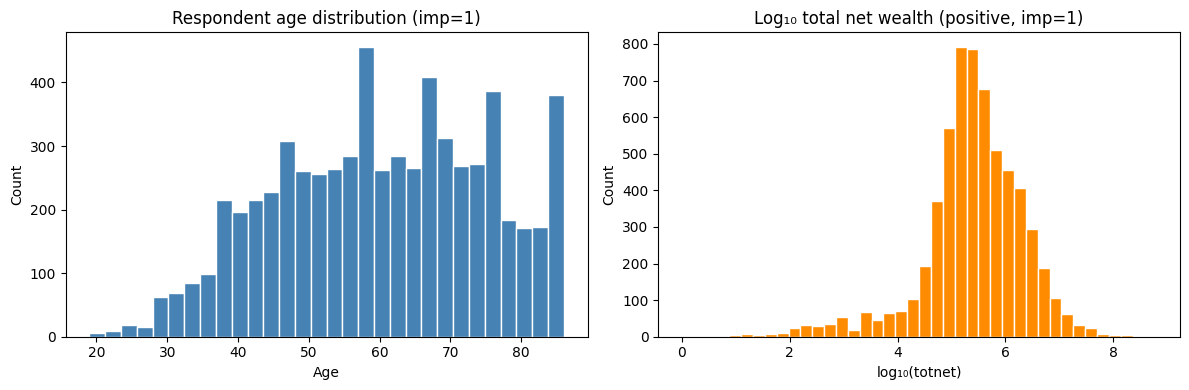

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age histogram
axes[0].hist(eff1["age_resp"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Respondent age distribution (imp=1)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Net wealth histogram (log scale, positive only)
pos_wealth = eff1["totnet"][eff1["totnet"] > 0]
axes[1].hist(np.log10(pos_wealth), bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Log₁₀ total net wealth (positive, imp=1)")
axes[1].set_xlabel("log₁₀(totnet)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 7 · `secondlang_prob.dta` – full table

In [33]:
sl.sort_values("educ_resp").reset_index(drop=True)

,educ_resp,p_knows_second_lang
0,1.0,0.148047
1,2.0,0.182426
2,3.0,0.222700
3,4.0,0.268941
4,6.0,0.377541
5,8.0,0.500000
6,9.0,0.562177
7,11.0,0.731059
8,12.0,0.777300
9,97.0,0.461075


## 8 · Free-form filter / slice
Edit the cell below to explore any subset you need.

In [34]:
# Example: households aged 30-40 with main residence, imp=1
(
    eff1
    .query("age_resp >= 30 and age_resp <= 40 and own == 1")
    [["h_2017", "age_resp", "gender_resp", "educ_resp",
      "hhsize", "totnet", "hh_inc", "own", "own_ot", "neg"]]
    .head(20)
)

,h_2017,age_resp,gender_resp,educ_resp,hhsize,totnet,hh_inc,own,own_ot,neg
38,1032.0,36.0,0.0,6.0,2.0,6.110000e+04,17268.000000,1.0,0.0,0.0
47,1040.0,35.0,1.0,1002.0,4.0,9.175500e+04,58356.000000,1.0,0.0,0.0
63,1055.0,40.0,1.0,1002.0,3.0,3.420000e+05,7200.000000,1.0,1.0,1.0
66,1058.0,32.0,0.0,1002.0,4.0,3.699480e+05,29232.000000,1.0,1.0,0.0
71,1062.0,32.0,1.0,8.0,2.0,1.734410e+05,0.000000,1.0,1.0,1.0
74,1065.0,40.0,1.0,1002.0,4.0,1.301977e+06,45600.000000,1.0,1.0,1.0
113,110.0,33.0,0.0,11.0,4.0,1.172300e+04,68400.000000,1.0,0.0,0.0
135,112.0,38.0,1.0,8.0,4.0,1.688530e+05,25200.000000,1.0,0.0,1.0
148,1131.0,36.0,1.0,1001.0,3.0,3.708200e+05,0.000000,1.0,1.0,1.0
163,1145.0,36.0,0.0,3.0,4.0,4.623900e+04,21792.000000,1.0,0.0,0.0


---
## 9 · `secondlang_prob.dta` — full explorer

In [35]:

# Education level labels (from codebook)
educ_labels = {
    1:    "Illiterate",
    2:    "Primary",
    3:    "Vocational (< ESO)",
    4:    "Lower secondary (ESO)",
    5:    "Vocational (ESO) [not in sl]",
    6:    "Upper secondary (Bachillerato)",
    7:    "Vocational (Bachillerato) [not in sl]",
    8:    "Specialised vocational / Higher",
    9:    "Post-secondary (2+ yr)",
    11:   "Master's degree",
    12:   "PhD",
    97:   "Other",
    1001: "Short-cycle university (Diplomado)",
    1002: "Long-cycle university (Licenciado)",
}

sl_view = (
    sl
    .assign(
        educ_resp   = sl["educ_resp"].astype(int),
        educ_label  = sl["educ_resp"].astype(int).map(educ_labels),
        in_eff_data = sl["educ_resp"].astype(int).map(
            lambda x: "✓ matched" if x not in (5, 7) else "✗ missing in sl"
        ),
    )
    .sort_values("educ_resp")
    .reset_index(drop=True)
    [["educ_resp", "educ_label", "p_knows_second_lang", "in_eff_data"]]
)

sl_view


,educ_resp,educ_label,p_knows_second_lang,in_eff_data
0,1,Illiterate,0.148047,✓ matched
1,2,Primary,0.182426,✓ matched
2,3,Vocational (< ESO),0.222700,✓ matched
3,4,Lower secondary (ESO),0.268941,✓ matched
4,6,Upper secondary (Bachillerato),0.377541,✓ matched
5,8,Specialised vocational / Higher,0.500000,✓ matched
6,9,Post-secondary (2+ yr),0.562177,✓ matched
7,11,Master's degree,0.731059,✓ matched
8,12,PhD,0.777300,✓ matched
9,97,Other,0.461075,✓ matched


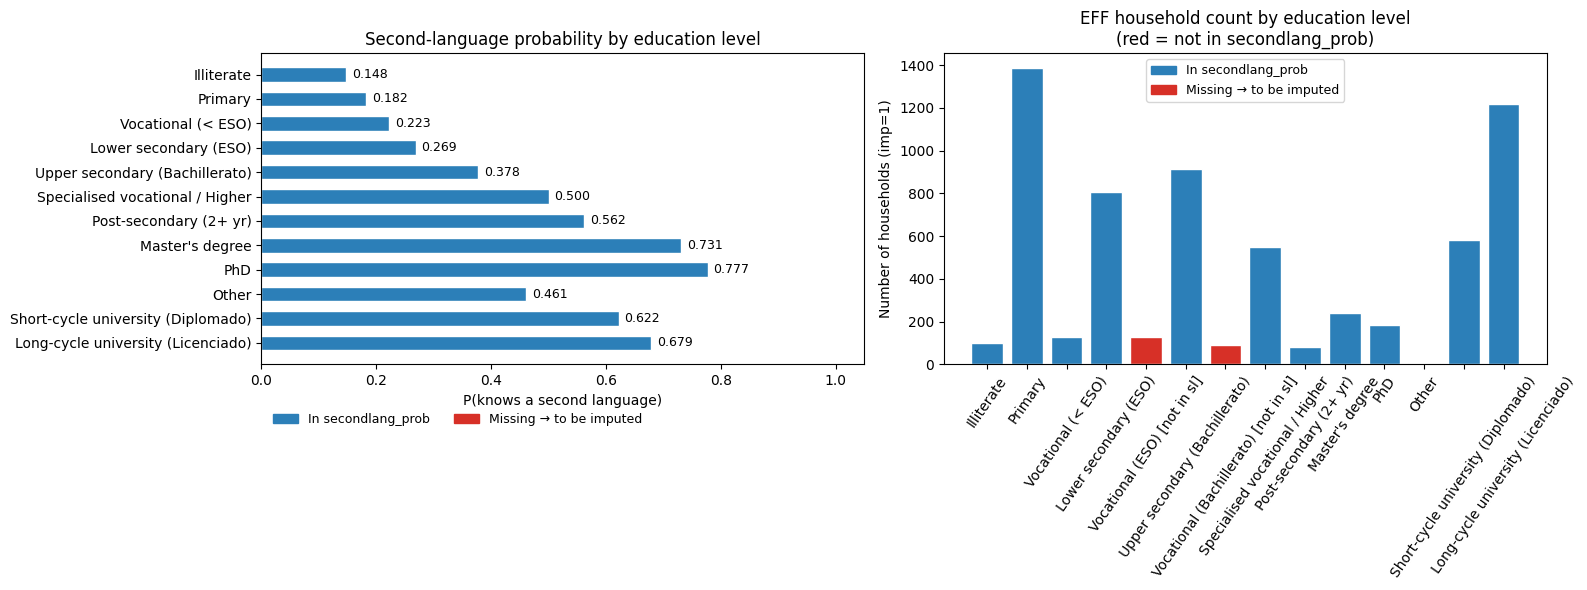


Households NOT matched in sl (educ 5 or 7): 220 (3.4%)


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: horizontal bar chart ---
colours = ["#2c7fb8" if x not in (5, 7) else "#d73027"
           for x in sl_view["educ_resp"]]

bars = axes[0].barh(
    sl_view["educ_label"],
    sl_view["p_knows_second_lang"],
    color=colours,
    edgecolor="white",
    height=0.6,
)
axes[0].set_xlabel("P(knows a second language)")
axes[0].set_title("Second-language probability by education level")
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, sl_view["p_knows_second_lang"]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=9)
axes[0].invert_yaxis()

blue_patch = mpatches.Patch(color="#2c7fb8", label="In secondlang_prob")
red_patch  = mpatches.Patch(color="#d73027", label="Missing → to be imputed")
axes[0].legend(
    handles=[blue_patch, red_patch],
    loc="upper left",
    bbox_to_anchor=(0, -0.12),
    ncol=2,
    frameon=False,
    fontsize=9,
)

# --- Right: merge coverage in eff (imp=1) ---
eff1_educ = eff[eff["imp"] == 1]["educ_resp"].astype(int)
sl_educ_set = set(sl["educ_resp"].astype(int))

coverage = (
    eff1_educ
    .value_counts()
    .reset_index()
    .rename(columns={"educ_resp": "educ_resp", "count": "n"})
    .assign(
        matched = lambda d: d["educ_resp"].isin(sl_educ_set),
        label   = lambda d: d["educ_resp"].map(educ_labels).fillna("Unknown"),
    )
    .sort_values("educ_resp")
)

bar_colours = ["#2c7fb8" if m else "#d73027" for m in coverage["matched"]]
axes[1].bar(coverage["label"], coverage["n"], color=bar_colours, edgecolor="white")
axes[1].set_ylabel("Number of households (imp=1)")
axes[1].set_title("EFF household count by education level\n(red = not in secondlang_prob)")
axes[1].tick_params(axis="x", rotation=55)
axes[1].legend(
    handles=[blue_patch, red_patch],
    loc="upper center",
    fontsize=9,
)

plt.tight_layout()
plt.show()

print(f"\nHouseholds NOT matched in sl (educ 5 or 7): "
      f"{(~eff1_educ.isin(sl_educ_set)).sum()} "
      f"({(~eff1_educ.isin(sl_educ_set)).mean()*100:.1f}%)")


## 10 · `secondlang_prob` — full education mapping with interpolated values

The dataset contains 12 of the 14 education codes found in `eff.dta`.  
Education levels **5** (Vocational, ESO entry) and **7** (Vocational, Bachillerato entry) are absent and filled by **linear midpoint interpolation** between their immediate neighbours:

- `educ = 5` → mean of `educ = 4` and `educ = 6`  
- `educ = 7` → mean of `educ = 6` and `educ = 8`

In [47]:
import pandas as pd

# Education code labels (including vocational tracks)
educ_label_map = {
    1:    "Illiterate",
    2:    "Primary",
    3:    "Vocational (< ESO)",
    4:    "Lower secondary (ESO)",
    5:    "Vocational (ESO entry) [interpolated]",
    6:    "Upper secondary (Bachillerato)",
    7:    "Vocational (Bachillerato entry) [interpolated]",
    8:    "Specialised vocational / Higher",
    9:    "Post-secondary (2+ yr, Bachillerato)",
    11:   "Master's degree",
    12:   "PhD",
    97:   "Other",
    1001: "Short-cycle university (Diplomado)",
    1002: "Long-cycle university (Licenciado)",
}

# Observed values from secondlang_prob.dta
sl_obs = sl.set_index("educ_resp")["p_knows_second_lang"].to_dict()

# Compute interpolated values
p4 = sl_obs[4.0]
p6 = sl_obs[6.0]
p8 = sl_obs[8.0]
p_educ5 = (p4 + p6) / 2   # midpoint between educ=4 and educ=6
p_educ7 = (p6 + p8) / 2   # midpoint between educ=6 and educ=8

# Build complete mapping (all 14 education codes)
all_codes = sorted(educ_label_map.keys())
rows = []
for code in all_codes:
    if code in sl_obs:
        prob = sl_obs[code]
        interpolated = False
    elif code == 5:
        prob = p_educ5
        interpolated = True
    elif code == 7:
        prob = p_educ7
        interpolated = True
    else:
        prob = float("nan")
        interpolated = False
    rows.append({
        "educ_resp": code,
        "Education level": educ_label_map[code],
        "P(knows 2nd language)": round(prob, 6),
        "Interpolated": "Yes" if interpolated else "",
    })

sl_full = pd.DataFrame(rows)

# First difference (Δ) and second difference (Δ²)
sl_full["Δ vs previous"] = sl_full["P(knows 2nd language)"].diff()
sl_full["Δ² (acceleration)"] = sl_full["Δ vs previous"].diff()

# Style: highlight interpolated rows in yellow
def highlight_interp(row):
    colour = "background-color: #fff9c4" if row["Interpolated"] == "Yes" else ""
    return [colour] * len(row)

def fmt_signed(x):
    return f"{x:+.4f}" if pd.notna(x) else "—"

sl_full.style \
    .apply(highlight_interp, axis=1) \
    .format({
        "P(knows 2nd language)": "{:.4f}",
        "Δ vs previous":       fmt_signed,
        "Δ² (acceleration)":   fmt_signed,
    }) \
    .set_caption(
        "P(knows second language) by education level — observed and interpolated values"
    ) \
    .hide(axis="index")


educ_resp,Education level,P(knows 2nd language),Interpolated,Δ vs previous,Δ² (acceleration)
1,Illiterate,0.1480,,—,—
2,Primary,0.1824,,+0.0344,—
3,Vocational (< ESO),0.2227,,+0.0403,+0.0059
4,Lower secondary (ESO),0.2689,,+0.0462,+0.0060
5,Vocational (ESO entry) [interpolated],0.3232,Yes,+0.0543,+0.0081
6,Upper secondary (Bachillerato),0.3775,,+0.0543,+0.0000
7,Vocational (Bachillerato entry) [interpolated],0.4388,Yes,+0.0612,+0.0069
8,Specialised vocational / Higher,0.5000,,+0.0612,+0.0000
9,"Post-secondary (2+ yr, Bachillerato)",0.5622,,+0.0622,+0.0009
11,Master's degree,0.7311,,+0.1689,+0.1067


In [48]:
import os

TAB_DIR = "output/tables"
os.makedirs(TAB_DIR, exist_ok=True)

lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\centering")
lines.append(r"\caption{P(knows second language) by education level — observed and interpolated values}")
lines.append(r"\label{tab:secondlang_interp}")
lines.append(r"\begin{tabular}{clcccc}")
lines.append(r"\toprule")
lines.append(r"\textit{educ\_resp} & Education level & $\hat{p}$ & Interpolated & $\Delta$ & $\Delta^2$ \\")
lines.append(r"\midrule")

for i, row in sl_full.iterrows():
    code   = int(row["educ_resp"])
    label  = row["Education level"].replace("&", r"\&").replace("[interpolated]", r"\textit{[interpolated]}")
    prob   = f"{row['P(knows 2nd language)']:.4f}"
    interp = r"\checkmark" if row["Interpolated"] == "Yes" else ""
    delta  = row["Δ vs previous"]
    delta2 = row["Δ² (acceleration)"]
    delta_str  = f"{delta:+.4f}"  if pd.notna(delta)  else "—"
    delta2_str = f"{delta2:+.4f}" if pd.notna(delta2) else "—"
    lines.append(fr"  {code} & {label} & {prob} & {interp} & {delta_str} & {delta2_str} \\")

lines.append(r"\bottomrule")
lines.append(r"\multicolumn{6}{l}{\rule{0pt}{1em}\textit{Notes:} Interpolated values use the midpoint between adjacent education levels.} \\")
lines.append(r"\multicolumn{6}{l}{\rule{0pt}{1em}$\Delta$ = first difference of $\hat{p}$ vs preceding code; $\Delta^2$ = change in $\Delta$ (acceleration).} \\")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

tex = "\n".join(lines)
out_path = os.path.join(TAB_DIR, "Q4a_secondlang_interp.tex")
with open(out_path, "w") as f:
    f.write(tex)

print(f"Table saved: {out_path}")
print()
print(tex)


Table saved: output/tables/Q4a_secondlang_interp.tex

\begin{table}[htbp]
\centering
\caption{P(knows second language) by education level — observed and interpolated values}
\label{tab:secondlang_interp}
\begin{tabular}{clcccc}
\toprule
\textit{educ\_resp} & Education level & $\hat{p}$ & Interpolated & $\Delta$ & $\Delta^2$ \\
\midrule
  1 & Illiterate & 0.1480 &  & — & — \\
  2 & Primary & 0.1824 &  & +0.0344 & — \\
  3 & Vocational (< ESO) & 0.2227 &  & +0.0403 & +0.0059 \\
  4 & Lower secondary (ESO) & 0.2689 &  & +0.0462 & +0.0060 \\
  5 & Vocational (ESO entry) \textit{[interpolated]} & 0.3232 & \checkmark & +0.0543 & +0.0081 \\
  6 & Upper secondary (Bachillerato) & 0.3775 &  & +0.0543 & +0.0000 \\
  7 & Vocational (Bachillerato entry) \textit{[interpolated]} & 0.4388 & \checkmark & +0.0612 & +0.0069 \\
  8 & Specialised vocational / Higher & 0.5000 &  & +0.0612 & +0.0000 \\
  9 & Post-secondary (2+ yr, Bachillerato) & 0.5622 &  & +0.0622 & +0.0009 \\
  11 & Master's degree & 0.7

---
## 11 · Merge diagnostics: key integrity checks

Two tests before merging `sl_raw` onto `eff1`:

1. **Duplicate keys in `sl`** — each `educ_resp` code should appear exactly once in the lookup table.  
2. **`sl` codes not in EFF** — any education codes present in the lookup but absent from `eff` (imp = 1) are dead weight and would never match.

In [49]:
import pandas as pd

eff1_educ_codes = set(eff[eff["imp"] == 1]["educ_resp"].astype(int).unique())
sl_codes        = set(sl["educ_resp"].astype(int).unique())

# ── Test 1: Duplicate keys in sl ─────────────────────────────────────────────
dup_counts = sl["educ_resp"].astype(int).value_counts()
duplicates = dup_counts[dup_counts > 1]

print("=" * 55)
print("TEST 1 — Duplicate educ_resp keys in sl")
print("=" * 55)
if duplicates.empty:
    print("  PASS  No duplicate keys found. Each educ_resp appears exactly once.")
else:
    print(f"  FAIL  {len(duplicates)} duplicate key(s) found:")
    print(duplicates.to_string())

# ── Test 2: sl codes not present in EFF (imp=1) ──────────────────────────────
sl_only = sl_codes - eff1_educ_codes

print()
print("=" * 55)
print("TEST 2 — educ_resp codes in sl but NOT in EFF (imp=1)")
print("=" * 55)
if not sl_only:
    print("  PASS  All sl codes exist in EFF. No unmatched lookup rows.")
else:
    print(f"  NOTE  {len(sl_only)} code(s) in sl have no matching household in EFF (imp=1):")
    dead_rows = (
        sl[sl["educ_resp"].astype(int).isin(sl_only)]
        .copy()
        .assign(educ_resp=lambda d: d["educ_resp"].astype(int))
        .sort_values("educ_resp")
        .reset_index(drop=True)
    )
    dead_rows["educ_label"] = dead_rows["educ_resp"].map(educ_label_map)
    display(dead_rows[["educ_resp", "educ_label", "p_knows_second_lang"]])

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  sl rows          : {len(sl)}")
print(f"  sl unique codes  : {len(sl_codes)}")
print(f"  EFF unique codes : {len(eff1_educ_codes)}")
print(f"  Codes in EFF ∩ sl: {len(sl_codes & eff1_educ_codes)}")
print(f"  EFF codes missing from sl  (need imputation) : {sorted(eff1_educ_codes - sl_codes)}")
print(f"  sl codes missing from EFF  (dead lookup rows): {sorted(sl_only) if sl_only else 'none'}")


TEST 1 — Duplicate educ_resp keys in sl
  PASS  No duplicate keys found. Each educ_resp appears exactly once.

TEST 2 — educ_resp codes in sl but NOT in EFF (imp=1)
  PASS  All sl codes exist in EFF. No unmatched lookup rows.

SUMMARY
  sl rows          : 12
  sl unique codes  : 12
  EFF unique codes : 14
  Codes in EFF ∩ sl: 12
  EFF codes missing from sl  (need imputation) : [np.int64(5), np.int64(7)]
  sl codes missing from EFF  (dead lookup rows): none


## 12 · With vs without second-language skills by education level

Grouped bar chart showing the share of respondents **with** (`p`) and **without** (`1 − p`) second-language skills at each education level, using the full mapping from section 10 (including interpolated values).

Saved: output/figures/Q4c_secondlang_by_educ.png


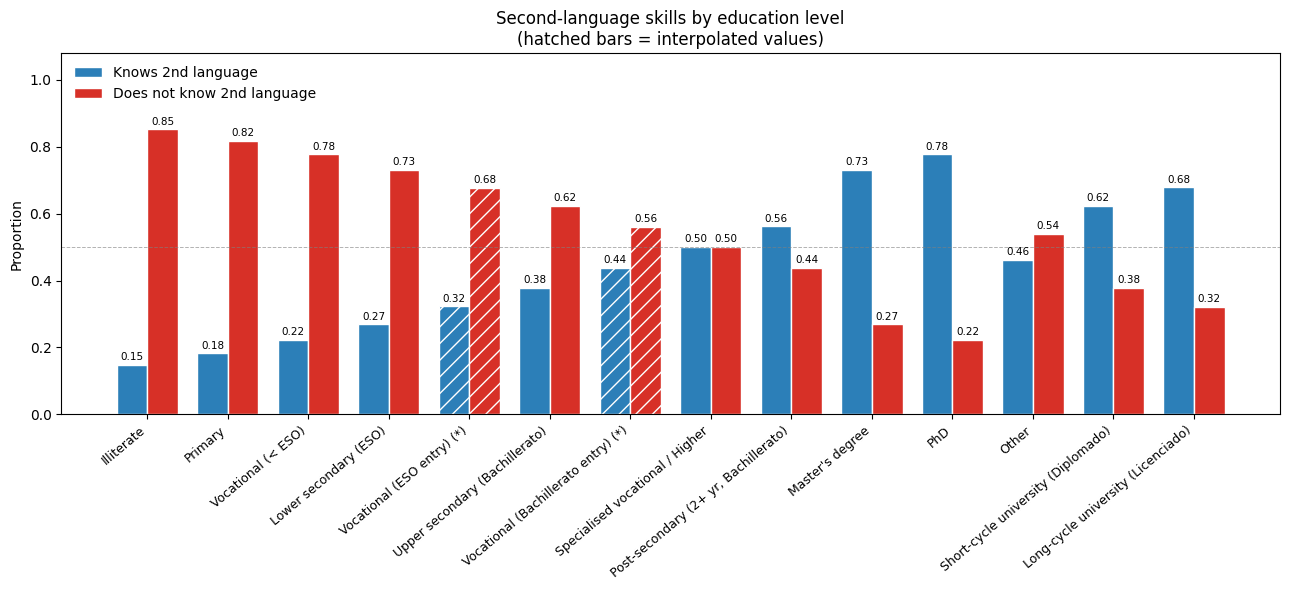

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Use sl_full from section 10 (includes interpolated rows)
labels  = sl_full["Education level"].str.replace(r"\[interpolated\]", "(*)", regex=True)
p_with  = sl_full["P(knows 2nd language)"].values
p_without = 1 - p_with
interp_mask = sl_full["Interpolated"] == "Yes"

x     = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))

bars_with    = ax.bar(x - width / 2, p_with,    width, label="Knows 2nd language",
                      color="#2c7fb8", edgecolor="white")
bars_without = ax.bar(x + width / 2, p_without, width, label="Does not know 2nd language",
                      color="#d73027", edgecolor="white")

# Mark interpolated bars with a hatch
for i, is_interp in enumerate(interp_mask):
    if is_interp:
        bars_with.patches[i].set_hatch("//")
        bars_without.patches[i].set_hatch("//")

# Value labels on top of each bar
for bar in list(bars_with) + list(bars_without):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
            f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.08)
ax.set_title("Second-language skills by education level\n(hatched bars = interpolated values)")
ax.legend(loc="upper left", frameon=False)
ax.axhline(0.5, color="grey", linewidth=0.7, linestyle="--", alpha=0.6)

plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/Q4c_secondlang_by_educ.png", dpi=150, bbox_inches="tight")
print("Saved: output/figures/Q4c_secondlang_by_educ.png")
plt.show()


Sample size (imp=1): 6,413 households
  Weighted % knowing a 2nd language  : 37.6%
  Weighted % NOT knowing a 2nd language: 62.4%


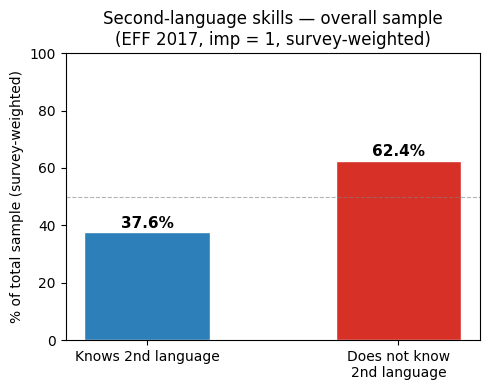

In [ ]:
import matplotlib.pyplot as plt
import os

# Map p_knows_second_lang onto every eff1 household (including interpolated values)
p_map = {**sl_obs, 5.0: p_educ5, 7.0: p_educ7}

eff1_lang = eff1.copy()
eff1_lang["p_lang"] = eff1_lang["educ_resp"].map(p_map)

# Survey-weighted aggregate (facine3 as weight)
total_w   = eff1_lang["facine3"].sum()
pct_with  = (eff1_lang["facine3"] * eff1_lang["p_lang"]).sum() / total_w * 100
pct_without = 100 - pct_with

n_total = len(eff1_lang)
print(f"Sample size (imp=1): {n_total:,} households")
print(f"  Weighted % knowing a 2nd language  : {pct_with:.1f}%")
print(f"  Weighted % NOT knowing a 2nd language: {pct_without:.1f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Knows 2nd language", "Does not know\n2nd language"],
    [pct_with, pct_without],
    color=["#2c7fb8", "#d73027"],
    edgecolor="white",
    width=0.5,
)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
            f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("% of total sample (survey-weighted)")
ax.set_ylim(0, 100)
ax.set_title("Second-language skills — overall sample\n(EFF 2017, imp = 1, survey-weighted)")
ax.axhline(50, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/Q4d_secondlang_overall.png", dpi=150, bbox_inches="tight")
print("Saved: output/figures/Q4d_secondlang_overall.png")
plt.show()
